In [103]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch

In [104]:
import matplotlib.pyplot as plt

# --- Global font settings ---
plt.rcParams["font.family"] = "Arial"

# Font sizes (you can adjust these)
plt.rcParams["font.size"] = 14         # base size
plt.rcParams["axes.titlesize"] = 14     # title
plt.rcParams["axes.labelsize"] = 14    # axis labels
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14

# Optional: make plots cleaner (publication style)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [105]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [106]:
pip install tensorboard

Note: you may need to restart the kernel to use updated packages.


In [107]:
## Set random seed for reproducibility
def set_seed(seed):
    """Set seed for reproducibility across libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # If using GPUs:
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For deterministic operations (optional, can slow things down):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Set seed
SEED = 77777
set_seed(SEED)

## Determine if a GPU is available and select the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## TensorBoard setup instructions (can be uncommented in a notebook)
%load_ext tensorboard
%tensorboard --logdir=runs --port=5678

Using device: cpu
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 5678 (pid 66121), started 2:34:01 ago. (Use '!kill 66121' to kill it.)

In [108]:
def stratified_sample(df, col, counts, seed=SEED):
    """
    Performs stratified sampling by extracting a specified number of samples from each bin of a column in the dataframe.
    The column is divided into bins, and a defined number of samples is taken from each bin.

    Args:
        df (pd.DataFrame): The input dataframe.
        col (str): The column used for creating bins, which serves as the basis for stratification.
        counts (list): Number of samples to extract from each bin, corresponding to each created bin.
        seed (int): Random seed for reproducibility.

    Returns:
        pd.DataFrame: Dataframe containing the extracted stratified samples.
    """
    np.random.seed(seed)
    df['grp'] = pd.cut(df[col], bins=len(counts))
    extracted = pd.concat(
        df[df['grp'] == grp].sample(cnt, replace=True, random_state=seed)
        for grp, cnt in zip(sorted(df['grp'].unique()), counts)
        )
    return extracted#.drop(columns=['grp'])


def getFeatures(df, feature='MGW'):
    # define valid features and their index ranges
    feature_map = {
        "MGW":  range(3, 18),
        "HelT": range(2, 18),
        "ProT": range(3, 18),
        "Roll": range(2, 18),
        }
    
    # check if the requested feature is valid
    if feature not in feature_map:
        raise ValueError(
            f"Invalid feature '{feature}'. "
            f"Valid options are: {list(feature_map.keys())}"
            )
    
    # build the column list for the chosen feature
    cols = [f"{feature}_{i:02d}" for i in feature_map[feature]]
    
    # check that all required columns exist in df
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in dataframe: {missing}")
    
    return df[cols]

In [109]:
df_UL = pd.read_csv("Up_library_merged_features_and_expr.csv", index_col=0)
df_UL = df_UL[(df_UL['LogGFP']>1) & (df_UL['LogGFP']<4)]

df_train = stratified_sample(df_UL, 'LogGFP', [500, 1000, 1500, 1500, 1000, 500])
df_train

,sequence,MGW_01,MGW_02,MGW_03,MGW_04,MGW_05,MGW_06,MGW_07,MGW_08,MGW_09,...,HelT_16,HelT_17,HelT_18,GC_frac,rep1,rep2,count1,count2,LogGFP,grp
seq_id,,,,,,,,,,,,,,,,,,,,,
seq_48689,CCCTGGAAATGGTTCCGAC,NaN,NaN,4.85,5.40,5.31,4.97,4.63,4.27,3.84,...,32.79,35.42,NaN,0.578947,1.905848,0.644671,33,14,1.275259,"(0.999, 1.35]"
seq_165930,ATTTGGCCAAGTTGTAGGT,NaN,NaN,4.12,5.42,5.56,4.93,4.93,5.56,5.31,...,31.44,34.99,NaN,0.421053,1.419035,1.209879,14,18,1.314457,"(0.999, 1.35]"
seq_61859,AAACCGCAGTAATGGATCC,NaN,NaN,4.06,4.36,5.08,5.59,5.67,5.40,5.13,...,32.41,36.29,NaN,0.473684,1.780855,0.909096,30,18,1.344976,"(0.999, 1.35]"
seq_27973,CGAGTCGGTTCAACAACTT,NaN,NaN,4.93,4.53,4.59,5.54,5.02,4.36,4.46,...,36.27,33.58,NaN,0.473684,0.984850,1.199963,15,21,1.092406,"(0.999, 1.35]"
seq_31978,ATAACGTACGAACCCAAAT,NaN,NaN,5.62,5.15,4.21,4.84,5.93,5.93,5.61,...,35.34,37.28,NaN,0.368421,1.853220,0.457031,18,13,1.155125,"(0.999, 1.35]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
seq_70043,TGGCTACAAGAGATAATAA,NaN,NaN,4.53,5.00,5.88,5.74,5.89,5.19,4.92,...,32.46,34.83,NaN,0.315789,2.859739,2.647690,22,21,2.753715,"(2.745, 3.094]"
seq_164763,CAAGTGCGCTATTAGAAAT,NaN,NaN,4.52,4.14,5.30,5.88,5.71,5.18,5.22,...,35.90,36.70,NaN,0.368421,3.031722,2.667522,14,14,2.849622,"(2.745, 3.094]"
seq_97225,TTCATAAACGTCTAAAAAC,NaN,NaN,5.50,5.84,6.02,5.66,5.10,4.43,4.21,...,37.57,36.95,NaN,0.263158,2.825794,3.083991,25,13,2.954893,"(2.745, 3.094]"


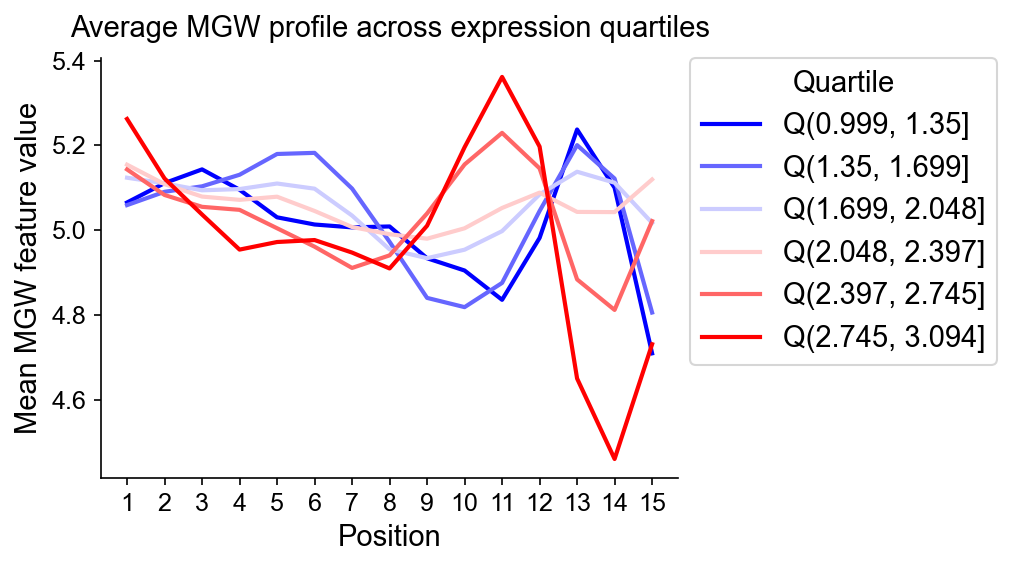

In [110]:
import matplotlib.pyplot as plt

grouped = df_train.groupby('grp', observed=True)
n_groups = grouped.ngroups
cmap = plt.get_cmap('bwr', n_groups)

fig, ax = plt.subplots(figsize=(7, 4))

for idx, (name, group) in enumerate(grouped):
    color = cmap(idx)
    y = getFeatures(group, "MGW").mean()
    ax.plot(y, color=color, linewidth=2, label=f"Q{name}")

# Title + axis labels
ax.set_title("Average MGW profile across expression quartiles", pad=10)
ax.set_xlabel("Position")
ax.set_ylabel("Mean MGW feature value")

# Hide x tick labels (keep ticks if you want)
ax.set_xticklabels([])

# Legend
ax.legend(title="Quartile", frameon=True)

# Add explanation text inside the plot
ax.legend(
    title="Quartile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)
n_pos = len(getFeatures(df_train, "MGW").mean())

plt.xticks(range(n_pos), range(1, n_pos+1))
fig.tight_layout()

# Save at 600 dpi
fig.savefig("MGW_quartiles_mean_profile.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [111]:
getFeatures(group, "MGW").mean().values

array([5.26262, 5.12208, 5.03714, 4.95434, 4.97224, 4.97688, 4.94732,
       4.90986, 5.01066, 5.19588, 5.36178, 5.1974 , 4.65018, 4.46026,
       4.73108])

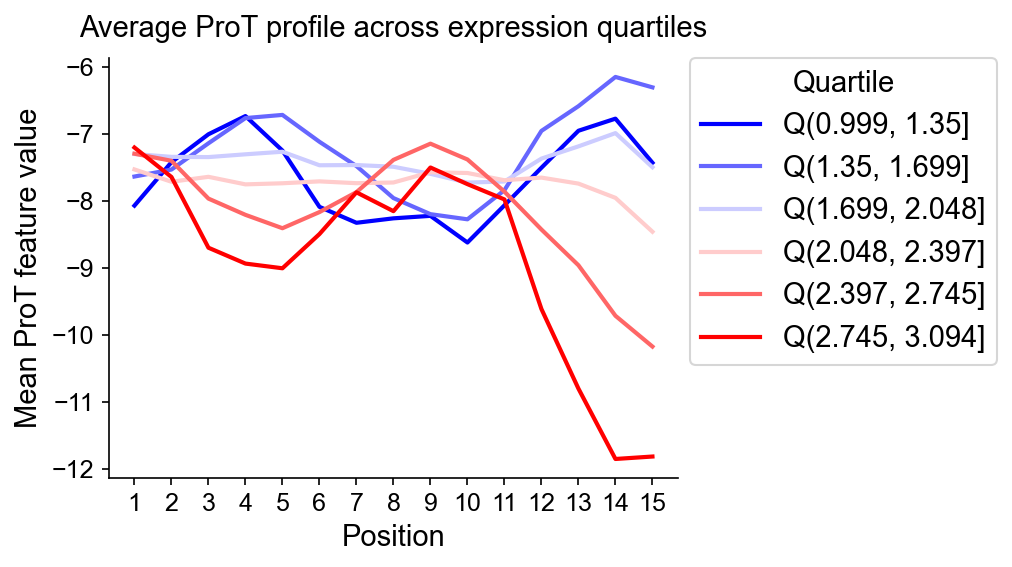

In [112]:
import matplotlib.pyplot as plt

grouped = df_train.groupby('grp', observed=True)
n_groups = grouped.ngroups
cmap = plt.get_cmap('bwr', n_groups)

fig, ax = plt.subplots(figsize=(7, 4))

for idx, (name, group) in enumerate(grouped):
    color = cmap(idx)
    y = getFeatures(group, "ProT").mean()
    ax.plot(y, color=color, linewidth=2, label=f"Q{name}")

# Title + axis labels
ax.set_title("Average ProT profile across expression quartiles", pad=10)
ax.set_xlabel("Position")
ax.set_ylabel("Mean ProT feature value")

# Hide x tick labels (keep ticks if you want)
ax.set_xticklabels([])

# Legend
ax.legend(title="Quartile", frameon=True)

# Add explanation text inside the plot
ax.legend(
    title="Quartile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)
n_pos = len(getFeatures(df_train, "MGW").mean())

plt.xticks(range(n_pos), range(1, n_pos+1))
fig.tight_layout()

# Save at 600 dpi
fig.savefig("ProT_quartiles_mean_profile.pdf", dpi=600, bbox_inches="tight")
plt.show()

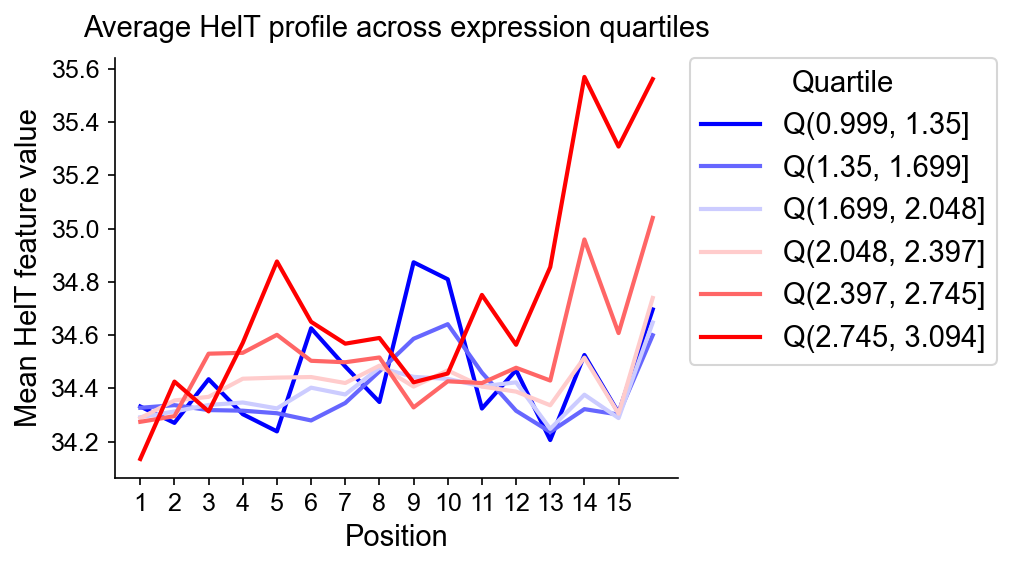

In [113]:
import matplotlib.pyplot as plt

grouped = df_train.groupby('grp', observed=True)
n_groups = grouped.ngroups
cmap = plt.get_cmap('bwr', n_groups)

fig, ax = plt.subplots(figsize=(7, 4))

for idx, (name, group) in enumerate(grouped):
    color = cmap(idx)
    y = getFeatures(group, "HelT").mean()
    ax.plot(y, color=color, linewidth=2, label=f"Q{name}")

# Title + axis labels
ax.set_title("Average HelT profile across expression quartiles", pad=10)
ax.set_xlabel("Position")
ax.set_ylabel("Mean HelT feature value")

# Hide x tick labels (keep ticks if you want)
ax.set_xticklabels([])

# Legend
ax.legend(title="Quartile", frameon=True)

# Add explanation text inside the plot
ax.legend(
    title="Quartile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)
n_pos = len(getFeatures(df_train, "MGW").mean())

plt.xticks(range(n_pos), range(1, n_pos+1))
fig.tight_layout()

# Save at 600 dpi
fig.savefig("HelT_quartiles_mean_profile.pdf", dpi=600, bbox_inches="tight")
plt.show()

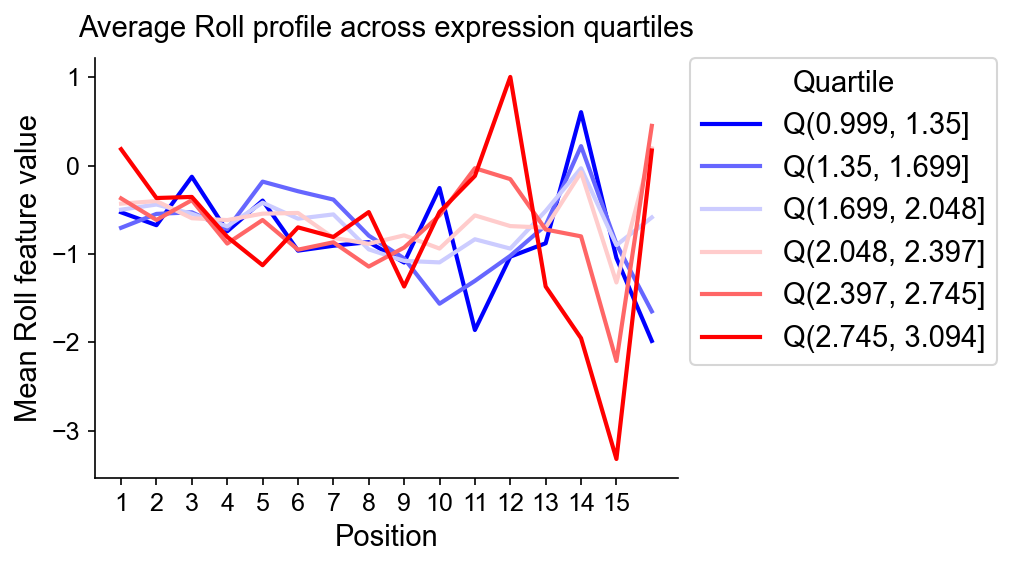

In [114]:
import matplotlib.pyplot as plt

grouped = df_train.groupby('grp', observed=True)
n_groups = grouped.ngroups
cmap = plt.get_cmap('bwr', n_groups)

fig, ax = plt.subplots(figsize=(7, 4))

for idx, (name, group) in enumerate(grouped):
    color = cmap(idx)
    y = getFeatures(group, "Roll").mean()
    ax.plot(y, color=color, linewidth=2, label=f"Q{name}")

# Title + axis labels
ax.set_title("Average Roll profile across expression quartiles", pad=10)
ax.set_xlabel("Position")
ax.set_ylabel("Mean Roll feature value")

# Hide x tick labels (keep ticks if you want)
ax.set_xticklabels([])

# Legend
ax.legend(title="Quartile", frameon=True)

# Add explanation text inside the plot
ax.legend(
    title="Quartile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)
n_pos = len(getFeatures(df_train, "MGW").mean())

plt.xticks(range(n_pos), range(1, n_pos+1))
fig.tight_layout()

# Save at 600 dpi
fig.savefig("Roll_quartiles_mean_profile.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [115]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomFunctionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # Trainable parameters
        F = torch.tensor([5.2589 , 5.17082, 5.05386, 4.97584, 4.9978 , 4.9089 , 4.88742, 4.87894, 5.03508, 5.24092, 5.35962, 5.1836 , 4.62548, 4.47278, 4.70394])
        self.E = nn.Parameter(torch.tensor(4.0))          # scalar
        self.F = nn.Parameter(F.clone().detach())#, requires_grad=False)         # optimal features
        self.w_raw = nn.Parameter(torch.ones(input_dim)) # unconstrained weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x if x.dim() > 1 else x.unsqueeze(0)  # ensure (batch, d)
        w = self.w_raw ** 2                       # convert to non-negative weights
        y = self.E - (torch.abs(x - self.F) * w).sum(dim=1)
        # y = self.E - (w * (x - self.F)**2).sum(dim=1)
        return y.squeeze(-1)

    def get_weights(self) -> torch.Tensor:
        """Return the non-negative weights actually used in the model."""
        return (self.w_raw ** 2).detach()


In [116]:
from sklearn.model_selection import train_test_split

X = getFeatures(df_train, "MGW").values.astype(np.float32)
y = df_train["LogGFP"].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)

Epoch  200 | Train Loss: 87.1903 | Val Loss: 85.7512
Epoch  400 | Train Loss: 18.8547 | Val Loss: 18.4587
Epoch  600 | Train Loss: 5.2331 | Val Loss: 5.0744
Epoch  800 | Train Loss: 1.7576 | Val Loss: 1.6878
Epoch 1000 | Train Loss: 0.8349 | Val Loss: 0.8052
Epoch 1200 | Train Loss: 0.5736 | Val Loss: 0.5632
Epoch 1400 | Train Loss: 0.4749 | Val Loss: 0.4735
Epoch 1600 | Train Loss: 0.4213 | Val Loss: 0.4247
Epoch 1800 | Train Loss: 0.3881 | Val Loss: 0.3939
Epoch 2000 | Train Loss: 0.3640 | Val Loss: 0.3714
Epoch 2200 | Train Loss: 0.3452 | Val Loss: 0.3540
Epoch 2400 | Train Loss: 0.3287 | Val Loss: 0.3384
Epoch 2600 | Train Loss: 0.3134 | Val Loss: 0.3240
Epoch 2800 | Train Loss: 0.3002 | Val Loss: 0.3115
Epoch 3000 | Train Loss: 0.2876 | Val Loss: 0.2990
Epoch 3200 | Train Loss: 0.2760 | Val Loss: 0.2871
Epoch 3400 | Train Loss: 0.2638 | Val Loss: 0.2748
Epoch 3600 | Train Loss: 0.2507 | Val Loss: 0.2619
Epoch 3800 | Train Loss: 0.2377 | Val Loss: 0.2495
Epoch 4000 | Train Loss: 0.

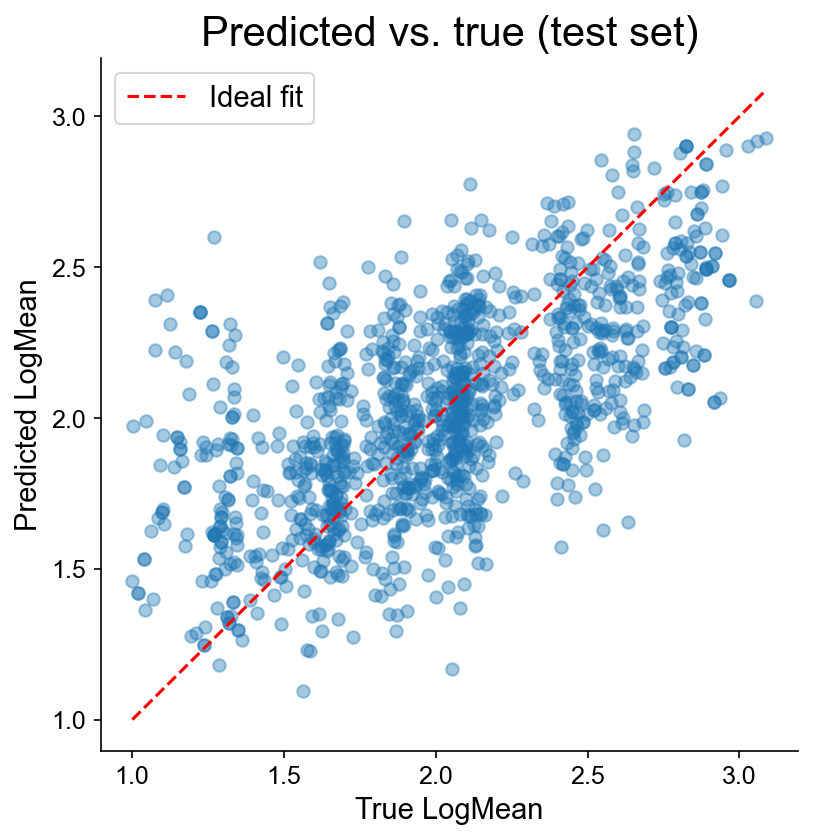

In [125]:
# ----- Train model -----
model = CustomFunctionModel(input_dim=X_train.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

best_val = float("inf")
patience = 20
patience_ctr = 0

for epoch in range(9000):
    model.train()
    optimizer.zero_grad()

    y_pred = model(X_train_t)
    loss = loss_fn(y_pred, y_train_t)

    loss.backward()
    optimizer.step()

    # validation every 200 epochs
    if (epoch + 1) % 200 == 0:
        model.eval()
        with torch.no_grad():
            y_val = model(X_test_t)
            val_loss = loss_fn(y_val, y_test_t).item()

        print(f"Epoch {epoch+1:4d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f}")

        # early stopping
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            patience_ctr = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print("Early stopping triggered.")
            break

# restore best model
model.load_state_dict(best_state)

# ----- Final evaluation plot -----
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).detach().cpu().numpy().ravel()
    y_true = y_test_t.detach().cpu().numpy().ravel()

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4)

lims = [
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max())
]
plt.plot(lims, lims, "r--", label="Ideal fit")

plt.xlabel("True LogMean")
plt.ylabel("Predicted LogMean")
plt.legend()
plt.title("Predicted vs. true (test set)", fontsize=20)
plt.savefig("predicted vs true values.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [118]:
print(X.shape)
print(model.F.shape)
print(model.get_weights().shape)

(6000, 15)
torch.Size([15])
torch.Size([15])


Input dim: 15


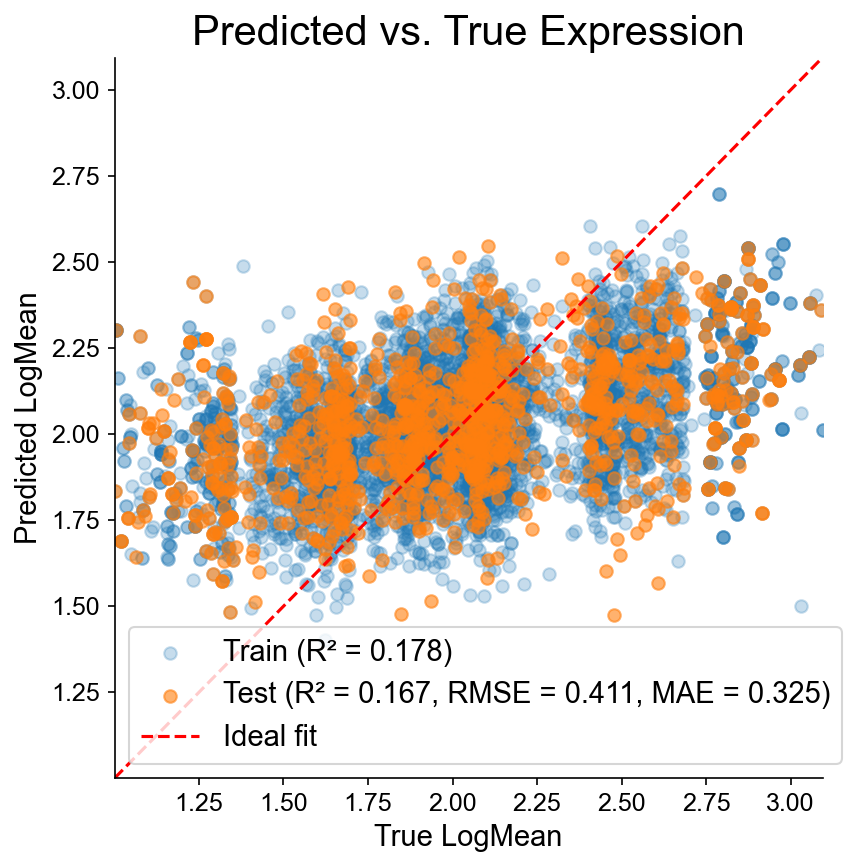

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
input_dim = X_train_t.shape[1]
print("Input dim:", input_dim)



# retrain model here

model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t).detach().cpu().numpy().ravel()
    y_true_train = y_train_t.detach().cpu().numpy().ravel()
    y_pred_test  = model(X_test_t).detach().cpu().numpy().ravel()
    y_true_test  = y_test_t.detach().cpu().numpy().ravel()

model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_t).detach().cpu().numpy().ravel()
    y_true_train = y_train_t.detach().cpu().numpy().ravel()
    y_pred_test  = model(X_test_t).detach().cpu().numpy().ravel()
    y_true_test  = y_test_t.detach().cpu().numpy().ravel()

# ---- Metrics ----
r2_train = r2_score(y_true_train, y_pred_train)
r2_test  = r2_score(y_true_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
mae_test  = mean_absolute_error(y_true_test, y_pred_test)

# ---- Plot ----
all_true = np.concatenate([y_true_train, y_true_test])
all_pred = np.concatenate([y_pred_train, y_pred_test])
lims = [min(all_true.min(), all_pred.min()), max(all_true.max(), all_pred.max())]

plt.figure(figsize=(6, 6))

plt.scatter(y_true_train, y_pred_train,
            alpha=0.25,
            label=f"Train (R² = {r2_train:.3f})")

plt.scatter(y_true_test, y_pred_test,
            alpha=0.6,
            label=f"Test (R² = {r2_test:.3f}, RMSE = {rmse_test:.3f}, MAE = {mae_test:.3f})")

plt.plot(lims, lims, "r--", label="Ideal fit")

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("True LogMean")
plt.ylabel("Predicted LogMean")
plt.title("Predicted vs. True Expression", fontsize=20)
plt.legend()
plt.tight_layout()

plt.savefig("train_test_performance.pdf", dpi=600, bbox_inches="tight")
plt.show()

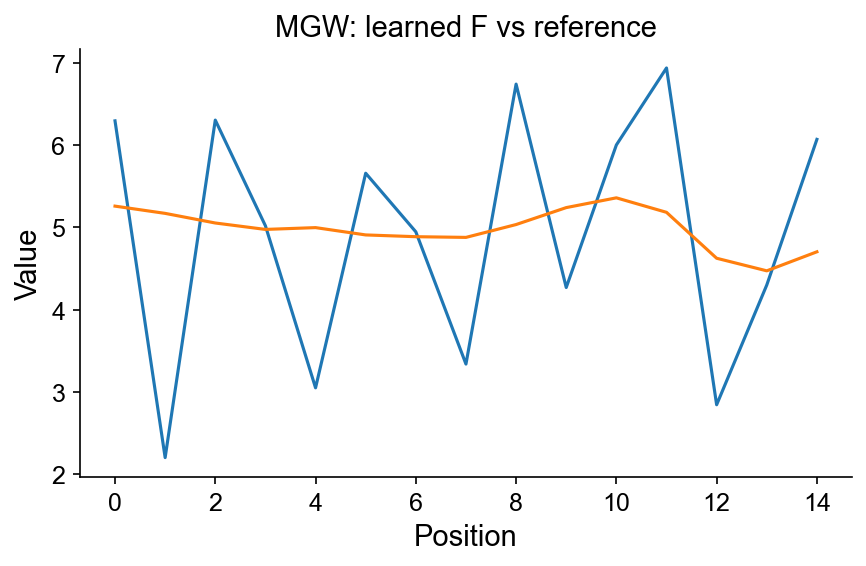

In [120]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))  # <-- must be first

ax.plot(model.F.detach().cpu().numpy())
ax.plot([5.2589 , 5.17082, 5.05386, 4.97584, 4.9978 , 4.9089 , 4.88742,
         4.87894, 5.03508, 5.24092, 5.35962, 5.1836 , 4.62548, 4.47278, 4.70394])

ax.set_ylabel("Value")
ax.set_xlabel("Position")
# your old ylabel didn't match what you're plotting
ax.set_title("MGW: learned F vs reference")

fig.tight_layout()
fig.savefig("train_test_MGW.pdf", dpi=600, bbox_inches="tight")
plt.show()

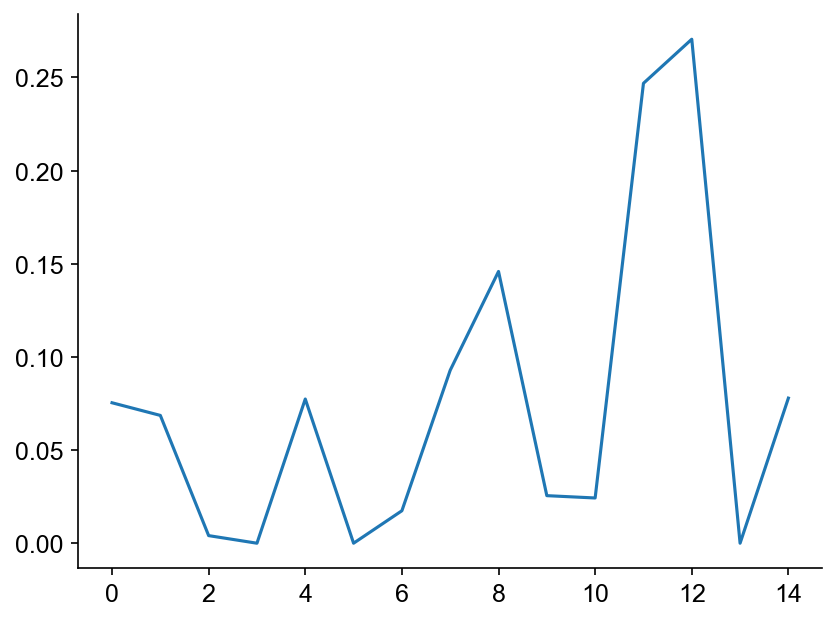

In [121]:
plt.plot(model.get_weights())

In [122]:
#new model with all 4 features befor only the mGW

In [123]:

import pandas as pd

X_all = pd.concat(
    [getFeatures(df_train, f) for f in ["MGW", "ProT", "HelT", "Roll"]],
    axis=1
).values.astype(np.float32)

print("X_all shape:", X_all.shape)





from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

import torch
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_all_scaled, y, test_size=0.2, random_state=42
)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

X_all shape: (6000, 62)


Feature lengths: {'MGW': 15, 'ProT': 15, 'HelT': 16, 'Roll': 16}
X_all shape: (6000, 62)
Epoch  200 | Train 87.1903 | Val 85.7512
Epoch  400 | Train 18.8547 | Val 18.4586
Epoch  600 | Train 5.2331 | Val 5.0744
Epoch  800 | Train 1.7576 | Val 1.6878
Epoch 1000 | Train 0.8349 | Val 0.8052
Epoch 1200 | Train 0.5736 | Val 0.5632
Epoch 1400 | Train 0.4749 | Val 0.4735
Epoch 1600 | Train 0.4213 | Val 0.4247
Epoch 1800 | Train 0.3881 | Val 0.3939
Epoch 2000 | Train 0.3640 | Val 0.3714
Epoch 2200 | Train 0.3452 | Val 0.3540
Epoch 2400 | Train 0.3287 | Val 0.3384
Epoch 2600 | Train 0.3134 | Val 0.3240
Epoch 2800 | Train 0.3002 | Val 0.3115
Epoch 3000 | Train 0.2876 | Val 0.2990
Epoch 3200 | Train 0.2760 | Val 0.2871
Epoch 3400 | Train 0.2638 | Val 0.2748
Epoch 3600 | Train 0.2507 | Val 0.2619
Epoch 3800 | Train 0.2377 | Val 0.2494
Epoch 4000 | Train 0.2263 | Val 0.2378
Epoch 4200 | Train 0.2158 | Val 0.2280
Epoch 4400 | Train 0.2061 | Val 0.2186
Epoch 4600 | Train 0.1974 | Val 0.2102
Epoch 4800

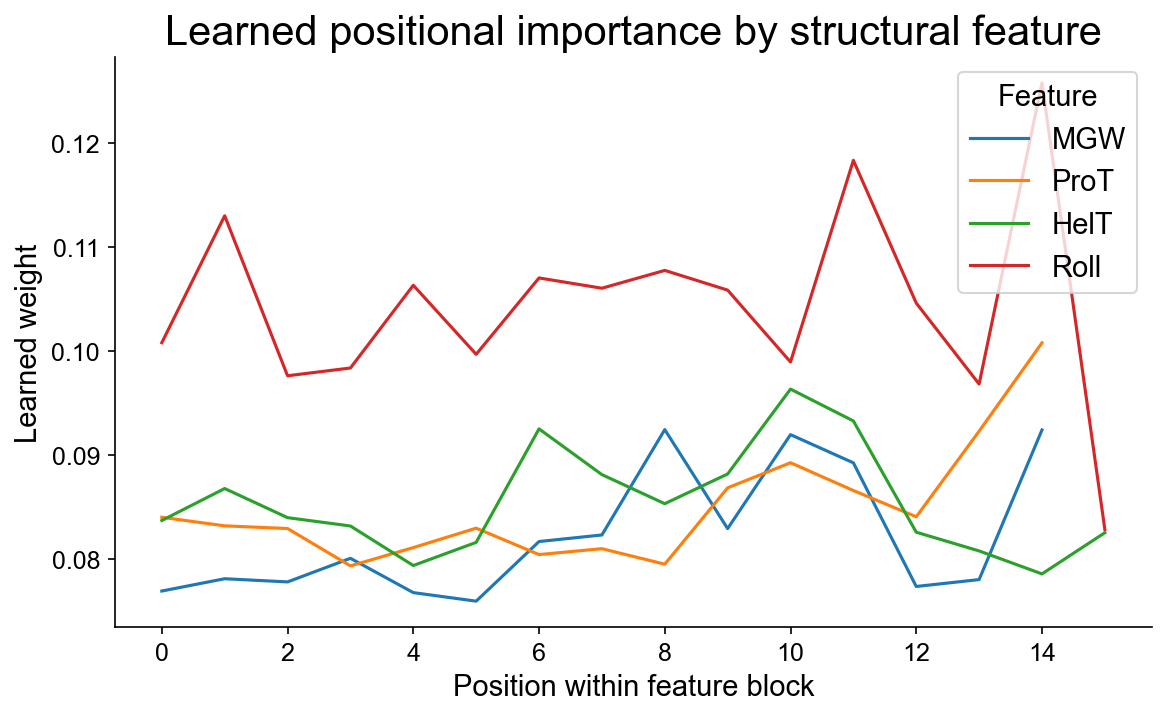

NameError: name 'totals' is not defined

<Figure size 900x600 with 0 Axes>

In [128]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

feature_names = ["MGW", "ProT", "HelT", "Roll"]

# build matrix by concatenating blocks
blocks = []
feature_lengths = {}
for f in feature_names:
    df_f = getFeatures(df_train, f)
    blocks.append(df_f)
    feature_lengths[f] = df_f.shape[1]

X_all_df = pd.concat(blocks, axis=1)
X_all = X_all_df.values.astype(np.float32)
y_all = df_train["LogGFP"].values.astype(np.float32)

print("Feature lengths:", feature_lengths)
print("X_all shape:", X_all.shape)  # expected: (n_samples, 62)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler
import torch

scaler = StandardScaler()
X_train_all_s = scaler.fit_transform(X_train_all).astype(np.float32)
X_test_all_s  = scaler.transform(X_test_all).astype(np.float32)

X_train_t = torch.tensor(X_train_all_s)
y_train_t = torch.tensor(y_train_all)
X_test_t  = torch.tensor(X_test_all_s)
y_test_t  = torch.tensor(y_test_all)
import torch.nn as nn
import torch.nn.functional as F

class CustomFunctionModel(nn.Module):
    def __init__(self, input_dim, F_init=None, E_init=4.0):
        super().__init__()
        self.E = nn.Parameter(torch.tensor(float(E_init)))

        if F_init is None:
            F_init = torch.zeros(input_dim, dtype=torch.float32)
        else:
            F_init = torch.tensor(F_init, dtype=torch.float32)

        self.F = nn.Parameter(F_init.clone().detach())      # (input_dim,)
        self.w_raw = nn.Parameter(torch.zeros(input_dim))   # start near 0

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        w = F.softplus(self.w_raw)  # positive, learnable
        return self.E - (torch.abs(x - self.F) * w).sum(dim=1)

    def get_weights(self):
        return F.softplus(self.w_raw).detach()

# init F from mean of TRAIN data (scaled space)
F0 = X_train_all_s.mean(axis=0)
model_all = CustomFunctionModel(input_dim=X_train_t.shape[1], F_init=F0)

optimizer = torch.optim.Adam(model_all.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

best_val = float("inf")
patience = 20
pat_ctr = 0

for epoch in range(5000):
    model_all.train()
    optimizer.zero_grad()
    pred = model_all(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 200 == 0:
        model_all.eval()
        with torch.no_grad():
            val_pred = model_all(X_test_t)
            val_loss = loss_fn(val_pred, y_test_t).item()

        print(f"Epoch {epoch+1:4d} | Train {loss.item():.4f} | Val {val_loss:.4f}")

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            pat_ctr = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model_all.state_dict().items()}
        else:
            pat_ctr += 1
            if pat_ctr >= patience:
                print("Early stopping.")
                break

model_all.load_state_dict(best_state)
print("model_all dim:", model_all.w_raw.numel())


import matplotlib.pyplot as plt
import numpy as np

w = model_all.get_weights().cpu().numpy().ravel()

total_len = sum(feature_lengths.values())
print("weights length:", len(w), "| expected:", total_len)
print("weights min/max/std:", w.min(), w.max(), w.std())

# slice automatically
slices = {}
start = 0
for f in feature_names:
    L = feature_lengths[f]
    slices[f] = w[start:start+L]
    start += L

# Plot 1: per-feature positional weights (each on its own x-axis)
plt.figure(figsize=(8, 5))
for f in feature_names:
    plt.plot(slices[f], label=f)

plt.xlabel("Position within feature block")
plt.ylabel("Learned weight")
plt.title("Learned positional importance by structural feature", fontsize=20)
plt.legend(title="Feature")
plt.tight_layout()
plt.savefig("weights_by_feature.pdf", dpi=600, bbox_inches="tight")
plt.show()

# Plot 2: total weight per feature




plt.figure(figsize=(6, 4))
plt.bar(list(totals.keys()), list(totals.values()))
plt.ylabel("Total weight (sum across positions)")
plt.title("Total structural feature importance")
plt.tight_layout()
plt.savefig("total_feature_importance.pdf", dpi=600, bbox_inches="tight")
plt.show()

Train R²: 0.03597837686538696
Test R²: 0.040183186531066895
Test RMSE: 0.4410931143247677
Test MAE: 0.35429009795188904


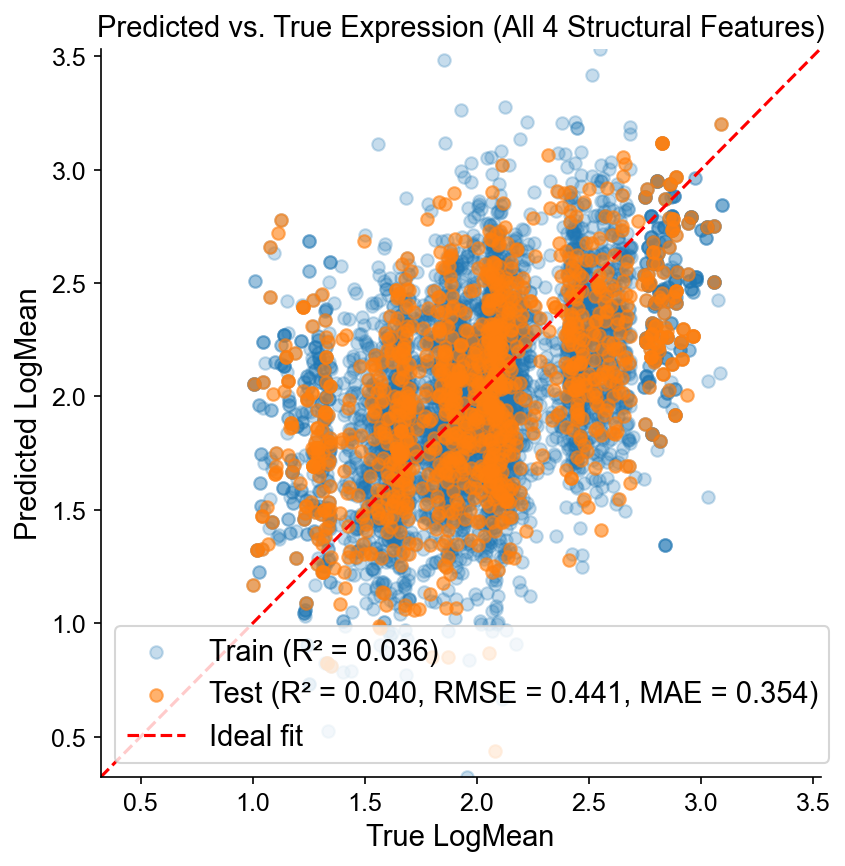

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

model_all.eval()

with torch.no_grad():
    y_pred_train = model_all(X_train_t).detach().cpu().numpy().ravel()
    y_true_train = y_train_t.detach().cpu().numpy().ravel()

    y_pred_test  = model_all(X_test_t).detach().cpu().numpy().ravel()
    y_true_test  = y_test_t.detach().cpu().numpy().ravel()

# ---- Metrics ----
r2_train = r2_score(y_true_train, y_pred_train)
r2_test  = r2_score(y_true_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
mae_test  = mean_absolute_error(y_true_test, y_pred_test)

print("Train R²:", r2_train)
print("Test R²:", r2_test)
print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)

# ---- Plot ----
all_true = np.concatenate([y_true_train, y_true_test])
all_pred = np.concatenate([y_pred_train, y_pred_test])
lims = [min(all_true.min(), all_pred.min()), max(all_true.max(), all_pred.max())]

plt.figure(figsize=(6, 6))

plt.scatter(y_true_train, y_pred_train,
            alpha=0.25,
            label=f"Train (R² = {r2_train:.3f})")

plt.scatter(y_true_test, y_pred_test,
            alpha=0.6,
            label=f"Test (R² = {r2_test:.3f}, RMSE = {rmse_test:.3f}, MAE = {mae_test:.3f})")

plt.plot(lims, lims, "r--", label="Ideal fit")

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("True LogMean")
plt.ylabel("Predicted LogMean")
plt.title("Predicted vs. True Expression (All 4 Structural Features)")
plt.legend()
plt.tight_layout()

plt.savefig("train_test_performance_all_features.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
w = model.get_weights().cpu().numpy().ravel()
print("weights min/max:", w.min(), w.max(), "std:", w.std())

weights min/max: 1.0 1.0 std: 0.0


In [ ]:
w_now = model.get_weights().detach().cpu().numpy().ravel()
print("before reload min/max/std:", w_now.min(), w_now.max(), w_now.std())

before reload min/max/std: 1.0 1.0 0.0
